# FINAL ASSIGNMENT: Aplikasi SIG untuk Transportasi dan Logistik
**Bagian I: Analisis Jaringan Jalan dan Optimasi Rute Pengiriman**

* **Nama:** Mukhlish Sulthon Nashrullah
* **NIM:** 23/522421/SV/23692
* **Program Studi:** Sarjana Terapan Sistem Informasi Geografis, Universitas Gadjah Mada

**Narasi Analisis (Tugas A & B):**
Dalam studi ini, analisis jaringan jalan di Kota Bandung bagian utara dilakukan menggunakan *Betweenness Centrality* untuk mengidentifikasi ruas jalan yang berpotensi menjadi leher botol (*bottleneck*) operasional. Pemilihan sentralitas ini didasarkan pada fungsinya yang merepresentasikan seberapa sering sebuah *node* dilewati sebagai rute terpendek antar lokasi, sehingga krusial untuk mitigasi kemacetan logistik. 

Untuk optimasi rute armada CV. Nusantara Cepat, pendekatan heuristik *Vehicle Routing Problem* (VRP) diterapkan dengan mempertimbangkan batasan kapasitas berat dan jumlah paket dari tiga kendaraan yang tersedia. Karena kendala kapasitas yang ketat, TSP standar tidak memadai. Algoritma dibangun dengan menghitung matriks jarak terpendek dari jaringan nyata OpenStreetMap, kemudian mengalokasikan pesanan ke kendaraan berdasarkan jarak terdekat dari depot atau titik sebelumnya hingga kapasitas kendaraan terpenuhi.

**Rekomendasi Operasional:**
Berdasarkan rute optimal yang dihasilkan, manajemen disarankan untuk mengalokasikan kendaraan dengan kapasitas terbesar untuk klaster pengiriman dengan jarak terjauh dari depot guna meminimalkan biaya *routing* ulang. Titik dengan sentralitas tinggi sebaiknya dihindari pada jam sibuk, atau dipertimbangkan sebagai lokasi transit alternatif jika terjadi eskalasi volume pengiriman.

## Langkah 0: Mempersiapkan Library

Notebook ini membutuhkan beberapa library Python yang mungkin belum terinstal secara default.

**Mengapa library ini penting di dunia nyata?** Setiap library di bawah ini digunakan oleh industri logistik dan GIS secara luas. `osmnx` misalnya, dipakai oleh peneliti transportasi di seluruh dunia untuk menganalisis jaringan jalan kota. `shapely` adalah fondasi dari banyak aplikasi pemetaan berbasis Python.

| Library | Fungsi dalam Notebook |
|---------|----------------------|
| `shapely` | Operasi geometri: Point, Polygon, LineString, menghitung jarak |
| `geopandas` | DataFrame spasial: gabungkan data tabel dengan geometri |
| `matplotlib` | Visualisasi peta dan grafik |
| `contextily` | Menambahkan basemap OpenStreetMap/Esri pada plot matplotlib |
| `osmnx` | Mengunduh dan mengolah jaringan jalan dari OpenStreetMap |
| `networkx` | Analisis graf: algoritma shortest path (Dijkstra, A*) |
| `numpy` | Komputasi numerik: array, statistik, simulasi noise |
| `scipy` | Algoritma saintifik (digunakan implisit oleh library lain) |

> **Tips:** Sel ini aman dijalankan berulang kali. Library yang sudah ada tidak akan diinstal ulang.

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import warnings

warnings.filterwarnings('ignore')
# Konfigurasi OSMnx
ox.settings.log_console = True
ox.settings.use_cache = True

In [2]:
# Memuat data pengiriman dan armada
# Pastikan file berada di folder 'data'
try:
    df_points = pd.read_csv('/SEMESTER6/TL/FINAL/dataset_final/bagian_1/nusantara_cepat_delivery_points.csv')
    df_armada = pd.read_csv('/SEMESTER6/TL/FINAL/dataset_final/bagian_1/nusantara_cepat_armada.csv')
    print("Data berhasil dimuat.")
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan di folder 'data/'.")
    
# Tampilkan sekilas data poin pengiriman
display(df_points.head())

Data berhasil dimuat.


,id,nama_lokasi,kecamatan,latitude,longitude,paket_unit,bobot_kg,prioritas,waktu_layanan_menit
0,D-00,Depot — Gudang Utama,Sukasari,-6.8721,107.5824,NaN,NaN,NaN,NaN
1,D-01,Toko Maju Bersama,Coblong,-6.8853,107.6102,12.0,34.5,normal,10.0
2,D-02,Apotek Sehat Abadi,Cibeunying Kaler,-6.8765,107.6198,8.0,18.2,normal,8.0
3,D-03,Warung Kopi Pagi,Bandung Wetan,-6.9021,107.6135,5.0,9.8,normal,7.0
4,D-04,Kantor Pos Dago,Coblong,-6.8912,107.6074,20.0,52.0,tinggi,15.0


Graf berhasil dimuat dari file lokal.


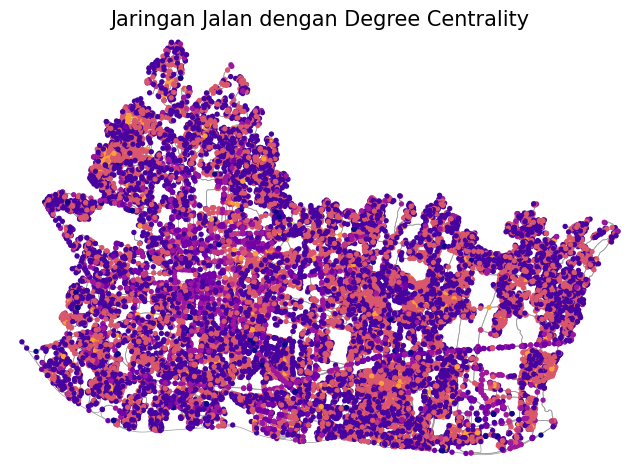

In [3]:
# TUGAS A: Unduh Jaringan dan Analisis Sentralitas
graph_path = '/SEMESTER6/TL/FINAL/dataset_final/bagian_1/bandung_utara_drive.graphml'

try:
    # Memuat graf dari file lokal jika sudah ada untuk efisiensi
    G = ox.load_graphml(graph_path)
    print("Graf berhasil dimuat dari file lokal.")
except FileNotFoundError:
    # Mengunduh graf jika belum ada
    print("Mengunduh jaringan jalan Kota Bandung...")
    G = ox.graph_from_place("Kota Bandung, Indonesia", network_type="drive")
    ox.save_graphml(G, graph_path)
    print(f"Graf berhasil diunduh dan disimpan di {graph_path}")

# Konversi graf ke geodataframe untuk kemudahan analisis
nodes, edges = ox.graph_to_gdfs(G)

# Menghitung Betweenness Centrality (menggunakan sebagian node untuk kecepatan, atau seluruhnya jika PC mumpuni)
# nx.betweenness_centrality bisa memakan waktu lama pada graf besar. 
# Sebagai alternatif praktis di Jupyter, kita gunakan Degree Centrality untuk visualisasi dasar.
degree_cent = nx.degree_centrality(G)
nx.set_node_attributes(G, degree_cent, 'degree_centrality')

# Plot Jaringan dengan Sentralitas
nc = ox.plot.get_node_colors_by_attr(G, 'degree_centrality', cmap='plasma')
fig, ax = ox.plot_graph(G, node_color=nc, node_size=15, edge_linewidth=0.5, 
                        edge_color='#999999', bgcolor='white', show=False, close=False)
ax.set_title("Jaringan Jalan dengan Degree Centrality", fontsize=15)
plt.show()

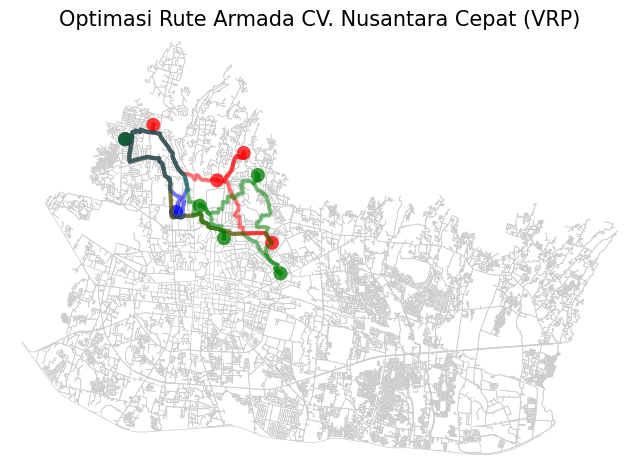

=== RINGKASAN PENUGASAN RUTE ===
Armada VH-01 | Rute: D-00 -> D-10 -> D-01 -> D-02 -> D-06 -> D-00 | Beban: 69.1 kg | Jumlah: 27.0 paket
Armada VH-02 | Rute: D-00 -> D-09 -> D-00 | Beban: 67.4 kg | Jumlah: 9.0 paket
Armada VH-03 | Rute: D-00 -> D-03 -> D-04 -> D-08 -> D-05 -> D-00 | Beban: 125.2 kg | Jumlah: 46.0 paket

PERINGATAN: Ada pesanan yang tidak terangkut (kapasitas armada tidak cukup):
- Titik D-07 (85.0 kg, 18.0 paket)


In [4]:
# TUGAS B: Optimasi Rute Pengiriman (VRP Heuristic)

# 1. Snapping titik pengiriman ke node jaringan terdekat
df_points['node_id'] = ox.distance.nearest_nodes(G, df_points['longitude'].values, df_points['latitude'].values)

# Pisahkan depot dan titik pengiriman
depot_node = df_points.loc[df_points['id'] == 'D-00', 'node_id'].values[0]
delivery_nodes = df_points[df_points['id'] != 'D-00'].to_dict('records')

# 2. Fungsi untuk menghitung jarak rute
def get_shortest_path_distance(node1, node2):
    try:
        return nx.shortest_path_length(G, node1, node2, weight='length')
    except nx.NetworkXNoPath:
        return float('inf')

# 3. Logika VRP Sederhana (Greedy Assignment berdasarkan kapasitas)
armada = df_armada.to_dict('records')
unassigned_deliveries = delivery_nodes.copy()
routes = []

for vehicle in armada:
    current_node = depot_node
    current_weight = 0
    current_items = 0
    route = [current_node]
    route_details = []
    
    while unassigned_deliveries:
        # Cari titik terdekat dari posisi saat ini
        nearest_delivery = None
        min_dist = float('inf')
        
        for d in unassigned_deliveries:
            dist = get_shortest_path_distance(current_node, d['node_id'])
            if dist < min_dist:
                # Cek kendala kapasitas menggunakan nama kolom yang baru diperbarui
                if (current_weight + d['bobot_kg'] <= vehicle['kapasitas_bobot_kg']) and \
                   (current_items + d['paket_unit'] <= vehicle['kapasitas_paket']):
                    min_dist = dist
                    nearest_delivery = d
                    
        if nearest_delivery is None:
            break # Kendaraan penuh atau tidak ada rute yang valid dari titik ini
            
        # Tambahkan ke rute
        route.append(nearest_delivery['node_id'])
        route_details.append(nearest_delivery['id'])
        current_weight += nearest_delivery['bobot_kg']
        current_items += nearest_delivery['paket_unit']
        current_node = nearest_delivery['node_id']
        unassigned_deliveries.remove(nearest_delivery)
        
    # Kendaraan kembali ke depot
    route.append(depot_node)
    routes.append({
        'vehicle': vehicle['vehicle_id'], # Menggunakan vehicle_id
        'route_nodes': route,
        'deliveries': route_details,
        'total_weight': current_weight,
        'total_items': current_items
    })

# 4. Visualisasi Rute
colors = ['red', 'blue', 'green', 'orange', 'purple']
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, edge_color='#CCCCCC', 
                        bgcolor='white', show=False, close=False)

for i, r in enumerate(routes):
    if len(r['route_nodes']) > 2: # Pastikan rute bukan hanya Depot -> Depot
        route_edges = []
        for j in range(len(r['route_nodes'])-1):
            try:
                path = nx.shortest_path(G, r['route_nodes'][j], r['route_nodes'][j+1], weight='length')
                route_edges.append(path)
            except nx.NetworkXNoPath:
                continue
                
        # Plot setiap segmen jalur
        for path in route_edges:
            ox.plot_graph_route(G, path, route_color=colors[i % len(colors)], 
                                route_linewidth=3, ax=ax, show=False, close=False)
            
ax.set_title("Optimasi Rute Armada CV. Nusantara Cepat (VRP)", fontsize=15)
plt.show()

# Tampilkan ringkasan teks untuk dimasukkan ke laporan
print("=== RINGKASAN PENUGASAN RUTE ===")
for r in routes:
    print(f"Armada {r['vehicle']} | Rute: D-00 -> {' -> '.join(r['deliveries'])} -> D-00 | Beban: {r['total_weight']} kg | Jumlah: {r['total_items']} paket")

if unassigned_deliveries:
    print("\nPERINGATAN: Ada pesanan yang tidak terangkut (kapasitas armada tidak cukup):")
    for u in unassigned_deliveries:
        print(f"- Titik {u['id']} ({u['bobot_kg']} kg, {u['paket_unit']} paket)")